Финансы.Табличные данные.
Предотвращение оттока клиентов. Прогнозирование вероятности оттока. Задача классификации.
Csv  файл на 10 тыс клиентов и информация по характеристикам (в т.ч. Метка оттока).. 18 колонок.

Датасет может быть больше

https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn/data


ТЕМА ПРОЕКТА: прогнозирование оттока клиентов банка — задача бинарной классификации.

ЦЕЛЬ ПРОЕКТА:на основе полученных данных  выяснить, что заставляет клиентов уходить(Exited)-(Значения целевой переменной:
0 — клиент остался;1 — клиент ушёл), и разработать стратегии, которые помогут банку.

 О ДАТАСЕТЕ
- RowNumber — соответствует номеру записи (строки) и не влияет на результат.

- CustomerId — содержит случайные значения и не влияет на решение клиента покинуть банк.

- Surname — фамилия клиента не влияет на его решение покинуть банк.
 -  CreditScore — может влиять на отток клиентов, поскольку клиент с более высоким кредитным рейтингом с меньшей вероятностью покинет банк.
 -  Geography — местоположение клиента может влиять на его решение покинуть банк.
 -  Gender — интересно изучить, играет ли пол роль в уходе клиента из банка.
  -  Age — это, безусловно, важно, поскольку клиенты старшего возраста реже покидают банк, чем клиенты младшего возраста.
  -  Tenure — указывает на количество лет, в течение которых клиент является клиентом банка. Обычно клиенты старшего возраста более лояльны и реже покидают банк.
  -  Balance — также очень хороший индикатор оттока клиентов, поскольку люди с большим остатком на счете реже покидают банк по сравнению с теми, у кого остаток меньше.
 -    NumOfProducts — указывает количество товаров, приобретенных клиентом через банк.
  - HasCrCard — указывает, есть ли у клиента кредитная карта. Этот столбец  также  важен, поскольку люди с кредитной картой реже покидают банк

  - IsActiveMember — активные клиенты реже покидают банк.

  - EstimatedSalary — как и в случае с балансом, люди с более низкими зарплатами чаще покидают банк, чем люди с более высокими зарплатами

  - Exited — покинул ли клиент банк.

  - Complaint — есть ли у клиента жалоба или нет.
  - Satisfaction Score — оценка, предоставленная клиентом за разрешение его жалобы.
  - Card Type — тип карты, которой владеет клиент.
  - Points Earned — баллы, заработанные клиентом за использование кредитной карты.
  
     Как известно, привлечение нового клиента обходится гораздо дороже, чем удержание существующего. Банкам выгодно знать, что побуждает клиента к решению покинуть компанию. Предотвращение оттока клиентов позволяет компаниям разрабатывать программы лояльности и кампании по удержанию клиентов, чтобы сохранить как можно больше клиентов.

In [ ]:
%pip install shap

In [ ]:
%pip -q install kagglehub

In [ ]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import glob
import warnings
import shap
import joblib

from pathlib import Path
from IPython.display import display
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#from google.colab import files

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
N_SPLITS = 5

In [5]:
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
path = Path(path)
print("Path:", path)

csv_files = sorted(path.glob("*.csv"))                                          #автоматически находим csv в папке
if not csv_files:
    raise FileNotFoundError(f"Файлы CSV не найдены в {path}")

df_raw = pd.read_csv(csv_files[0])                                              #загружаем исходный датасет
print("Loaded:", csv_files[0].name, df_raw.shape)

df = df_raw.copy()                                                              #создаем рабочую копию

Using Colab cache for faster access to the 'bank-customer-churn' dataset.
Path: /kaggle/input/bank-customer-churn
Loaded: Customer-Churn-Records.csv (10000, 18)


In [6]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [9]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [10]:
df.shape

(10000, 18)

In [11]:
df["Exited"].value_counts()

,count
Exited,
0,7962
1,2038


In [12]:
print("Количество дубликатов:")
print(df.duplicated().sum())

Количество дубликатов:
0


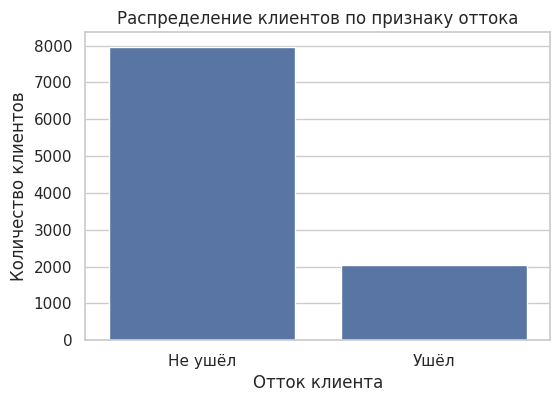

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Exited")

plt.title("Распределение клиентов по признаку оттока")
plt.xlabel("Отток клиента")
plt.ylabel("Количество клиентов")

plt.xticks([0, 1], ["Не ушёл", "Ушёл"])

plt.show()

In [14]:
complain_table = pd.crosstab(
    df["Complain"],
    df["Exited"],
    margins=True
)

complain_table.index = ["Нет жалобы", "Есть жалоба", "Всего"]
complain_table.columns = ["Не ушёл", "Ушёл", "Всего"]

display(complain_table)

,Не ушёл,Ушёл,Всего
Нет жалобы,7952,4,7956
Есть жалоба,10,2034,2044
Всего,7962,2038,10000


In [15]:
complain_churn_rate = (
    df.groupby("Complain")["Exited"]
    .agg(["mean", "count", "sum"])
    .rename(columns={
        "mean": "Доля оттока",
        "count": "Всего клиентов",
        "sum": "Ушло клиентов"
    })
)

complain_churn_rate["Доля оттока, %"] = (
    complain_churn_rate["Доля оттока"] * 100
).round(2)

complain_churn_rate.index = ["Нет жалобы", "Есть жалоба"]

display(complain_churn_rate)

,Доля оттока,Всего клиентов,Ушло клиентов,"Доля оттока, %"
Нет жалобы,0.000503,7956,4,0.05
Есть жалоба,0.995108,2044,2034,99.51


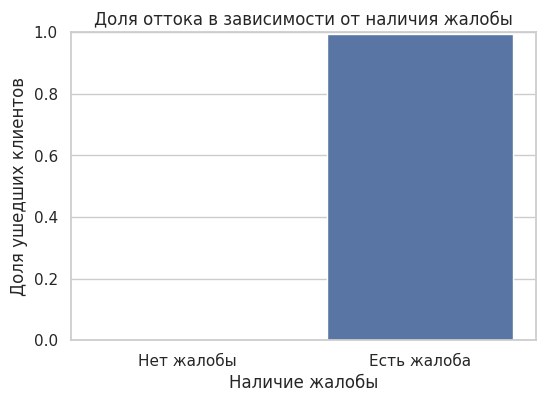

In [16]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x="Complain",
    y="Exited",
    errorbar=None
)

plt.title("Доля оттока в зависимости от наличия жалобы")
plt.xlabel("Наличие жалобы")
plt.ylabel("Доля ушедших клиентов")

plt.xticks([0, 1], ["Нет жалобы", "Есть жалоба"])
plt.ylim(0, 1)

plt.show()

Был проанализирован признак Complain. Если среди клиентов с жалобой доля оттока существенно выше, чем среди клиентов без жалобы, данный признак имеет сильную связь с целевой переменной Exited. Однако время появления жалобы в данных не указано. Жалоба может быть зарегистрирована после решения клиента об уходе или непосредственно перед ним. Поэтому включение Complain в модель может создать риск утечки целевой переменной и искусственно улучшить метрики. По этой причине признак будет исключён из основной модели.

In [17]:

df = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Complain'], axis=1)
print("Новый размер таблицы:", df.shape)

text_columns = df.select_dtypes('object').columns
print("Колонки с текстом:", text_columns)

Новый размер таблицы: (10000, 14)
Колонки с текстом: Index(['Geography', 'Gender', 'Card Type'], dtype='object')


In [18]:
age_groups = pd.cut(
    df["Age"],
    bins=[17, 30, 40, 50, 60, 100],
    labels=["18–30", "31–40", "41–50", "51–60", "61+"]
)

age_churn = df.groupby(age_groups, observed=True)["Exited"].mean() * 100

age_churn

,Exited
Age,
18–30,7.520325
31–40,12.109638
41–50,33.965517
51–60,56.210790
61+,24.784483


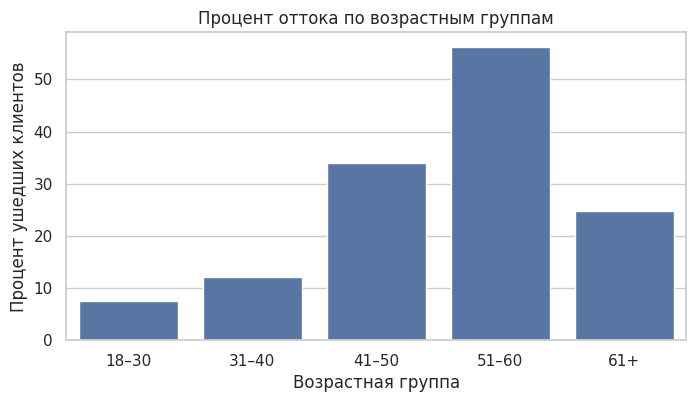

In [19]:
plt.figure(figsize=(8, 4))

sns.barplot(
    x=age_churn.index,
    y=age_churn.values
)

plt.title("Процент оттока по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Процент ушедших клиентов")

plt.show()

Наиболее высокий процент оттока наблюдается среди клиентов в возрасте от 51 до 60 лет. Также повышенный уровень оттока характерен для группы 41–50 лет. Среди молодых клиентов 18–30 лет отток минимальный.

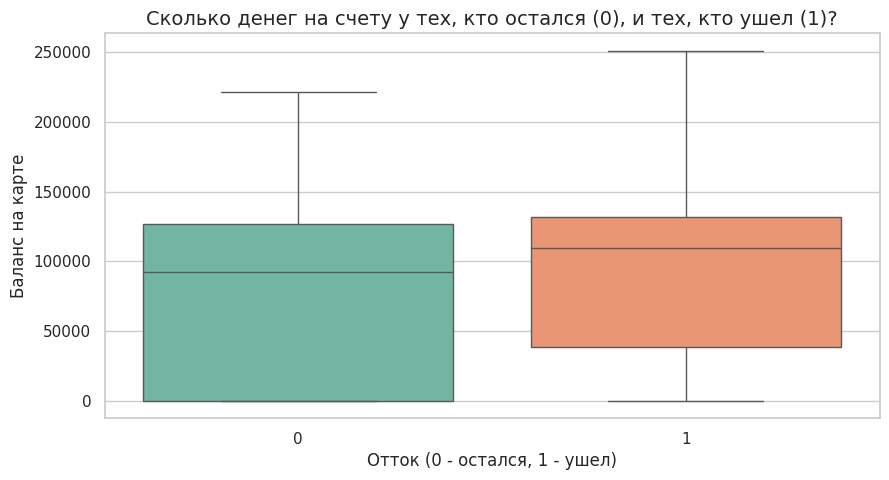

In [20]:
plt.figure(figsize=(10, 5))                                                     #влияние баланса на счету на решение уйти

sns.boxplot(data=df, x="Exited", y="Balance", palette="Set2")

plt.title("Сколько денег на счету у тех, кто остался (0), и тех, кто ушел (1)?", fontsize=14)
plt.xlabel("Отток (0 - остался, 1 - ушел)", fontsize=12)
plt.ylabel("Баланс на карте", fontsize=12)
plt.show()

Медианный баланс у ушедших клиентов немного выше, чем у оставшихся. Однако распределения баланса существенно перекрываются, поэтому связь между балансом и оттоком выглядит слабой. Баланс может быть полезен модели вместе с другими признаками, но сам по себе не является достаточным признаком оттока.

In [21]:
geography_churn = df.groupby("Geography")["Exited"].mean() * 100
geography_churn

,Exited
Geography,
France,16.174711
Germany,32.443204
Spain,16.673395


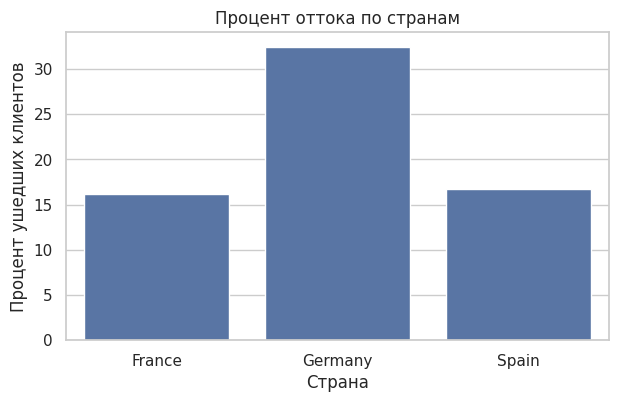

In [22]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=geography_churn.index,
    y=geography_churn.values
)

plt.title("Процент оттока по странам")
plt.xlabel("Страна")
plt.ylabel("Процент ушедших клиентов")

plt.show()

In [23]:
geography_churn = (
    df.groupby("Geography")["Exited"]
    .agg(["mean", "count", "sum"])
    .rename(columns={
        "mean": "Доля оттока",
        "count": "Всего клиентов",
        "sum": "Ушло клиентов"
    })
)

geography_churn["Доля оттока, %"] = (
    geography_churn["Доля оттока"] * 100
).round(2)

display(geography_churn)

,Доля оттока,Всего клиентов,Ушло клиентов,"Доля оттока, %"
Geography,,,,
France,0.161747,5014,811,16.17
Germany,0.324432,2509,814,32.44
Spain,0.166734,2477,413,16.67


У клиентов из Германии наблюдается более высокая доля оттока — 32,44%, тогда как во Франции и Испании она составляет около 16–17%.

In [24]:
products_churn = (
    df.groupby("NumOfProducts")["Exited"]
    .agg(["mean", "count", "sum"])
    .rename(columns={
        "mean": "Доля оттока",
        "count": "Всего клиентов",
        "sum": "Ушло клиентов"
    })
)

products_churn["Доля оттока, %"] = (
    products_churn["Доля оттока"] * 100
).round(2)

display(products_churn)

,Доля оттока,Всего клиентов,Ушло клиентов,"Доля оттока, %"
NumOfProducts,,,,
1,0.277144,5084,1409,27.71
2,0.076035,4590,349,7.60
3,0.827068,266,220,82.71
4,1.000000,60,60,100.00


Наименьший уровень оттока наблюдается у клиентов с двумя продуктами. У клиентов с тремя и четырьмя продуктами отток значительно выше, однако эти категории представлены существенно меньшим числом клиентов, поэтому результат следует интерпретировать с осторожностью.Наиболее многочисленными являются группы клиентов с одним и двумя продуктами.

In [25]:
activity_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100

activity_churn

,Exited
IsActiveMember,
0,26.871520
1,14.269074


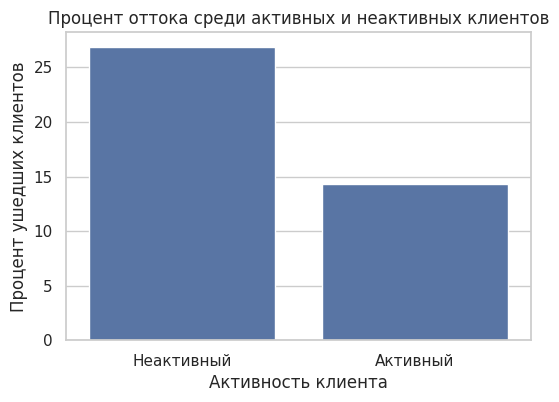

In [26]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=activity_churn.index,
    y=activity_churn.values
)

plt.title("Процент оттока среди активных и неактивных клиентов")
plt.xlabel("Активность клиента")
plt.ylabel("Процент ушедших клиентов")

plt.xticks([0, 1], ["Неактивный", "Активный"])

plt.show()

Неактивные клиенты покидают банк почти в два раза чаще, чем активные.

In [27]:
card_churn = df.groupby("HasCrCard")["Exited"].mean() * 100

card_churn

,Exited
HasCrCard,
0,20.814941
1,20.198441


In [28]:
gender_churn = df.groupby("Gender")["Exited"].mean() * 100

gender_churn

,Exited
Gender,
Female,25.071539
Male,16.474253


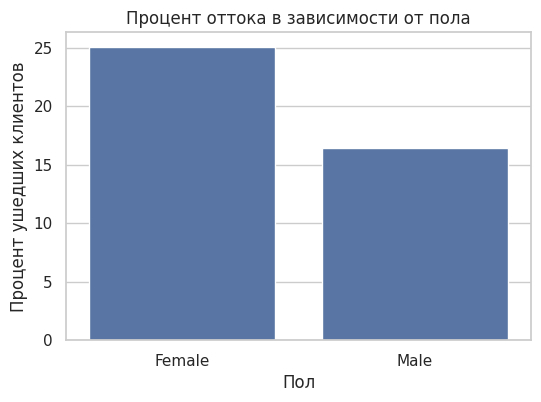

In [29]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.title("Процент оттока в зависимости от пола")
plt.xlabel("Пол")
plt.ylabel("Процент ушедших клиентов")

plt.show()

Среди женщин процент оттока заметно выше, чем среди мужчин

In [30]:
df.groupby("Tenure")["Exited"].mean() * 100           #доля ушедших клиентов для каждого срока обслуживания

,Exited
Tenure,
0,23.002421
1,22.415459
2,19.179389
3,21.110010
4,20.525784
5,20.652174
6,20.268873
7,17.217899
8,19.219512


Явной сильной зависимости между Tenure и Exited  не наблюдается



In [31]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [32]:
X.shape, y.shape

((10000, 13), (10000,))

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [34]:
X_train.shape, X_test.shape

((8000, 13), (2000, 13))

In [35]:
print("Полный датасет:")
print(y.value_counts(normalize=True) * 100)

print("\nTrain:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)

Полный датасет:
Exited
0    79.62
1    20.38
Name: proportion, dtype: float64

Train:
Exited
0    79.625
1    20.375
Name: proportion, dtype: float64

Test:
Exited
0    79.6
1    20.4
Name: proportion, dtype: float64


In [36]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Числовые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

Числовые признаки:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']

Категориальные признаки:
['Geography', 'Gender', 'Card Type']


In [37]:
numeric_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary',
    'Satisfaction Score',
    'Point Earned'
]

onehot_features = ['Geography', 'Gender', 'Card Type']
binary_features = ['HasCrCard', 'IsActiveMember']

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'onehot',
            OneHotEncoder(handle_unknown='ignore'),    #Если вдруг в новых данных встретится категория, которой модель раньше не видела, не выдавай ошибку
            onehot_features
        ),
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
          ('bin', 'passthrough',
           binary_features)
    ]
)

In [39]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000,class_weight="balanced",
                                     random_state=RANDOM_STATE))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=300,
                                        class_weight="balanced",
                                        random_state=RANDOM_STATE,))
    ]),

    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(n_estimators=100,
                                             random_state=RANDOM_STATE))
    ])
}

In [40]:
for name, model in models.items():
    model.fit(X_train, y_train)

In [41]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['onehot__Geography_France', 'onehot__Geography_Germany',
       'onehot__Geography_Spain', 'onehot__Gender_Female',
       'onehot__Gender_Male', 'onehot__Card Type_DIAMOND',
       'onehot__Card Type_GOLD', 'onehot__Card Type_PLATINUM',
       'onehot__Card Type_SILVER', 'num__CreditScore', 'num__Age',
       'num__Tenure', 'num__Balance', 'num__NumOfProducts',
       'num__EstimatedSalary', 'num__Satisfaction Score',
       'num__Point Earned', 'bin__HasCrCard', 'bin__IsActiveMember'],
      dtype=object)

Для решения задачи были обучены и сравнены три алгоритма: Logistic Regression с учётом дисбаланса классов, Random Forest и Gradient Boosting. В качестве основных метрик использовались ROC-AUC, Recall и F1-score для класса ушедших клиентов.

In [42]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [43]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        }
    )

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    })

In [44]:
cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.709875,0.382409,0.689571,0.491812,0.766305
1,Random Forest,0.858125,0.803270,0.402454,0.536056,0.853396
2,Gradient Boosting,0.862500,0.771558,0.461963,0.577739,0.861833


По результатам стратифицированной 5-кратной кросс-валидации среди базовых моделей лучшим оказался Gradient Boosting с ROC-AUC 0,8619. Далее для CatBoost был проведён подбор гиперпараметров с использованием встроенного метода grid_search и 5-кратной кросс-валидации.

In [45]:

cat_features = onehot_features

In [46]:
cb_grid_model = CatBoostClassifier(
    cat_features=cat_features,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=False
)

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'iterations': [200, 300]
}

grid_search_result = cb_grid_model.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=N_SPLITS,
    plot=False
)

print("Лучшие параметры:", grid_search_result['params'])


bestTest = 0.4651543191
bestIteration = 199

0:	loss: 0.4651543	best: 0.4651543 (0)	total: 2.59s	remaining: 44s

bestTest = 0.4574365387
bestIteration = 198

1:	loss: 0.4574365	best: 0.4574365 (1)	total: 4.59s	remaining: 36.8s

bestTest = 0.4566938303
bestIteration = 165

2:	loss: 0.4566938	best: 0.4566938 (2)	total: 6.26s	remaining: 31.3s

bestTest = 0.4604548676
bestIteration = 299

3:	loss: 0.4604549	best: 0.4566938 (2)	total: 8.84s	remaining: 31s

bestTest = 0.4558540583
bestIteration = 297

4:	loss: 0.4558541	best: 0.4558541 (4)	total: 11.4s	remaining: 29.6s

bestTest = 0.4566938303
bestIteration = 165

5:	loss: 0.4566938	best: 0.4558541 (4)	total: 14.2s	remaining: 28.4s

bestTest = 0.4621494073
bestIteration = 199

6:	loss: 0.4621494	best: 0.4558541 (4)	total: 17.3s	remaining: 27.3s

bestTest = 0.4555000412
bestIteration = 199

7:	loss: 0.4555000	best: 0.4555000 (7)	total: 19.5s	remaining: 24.3s

bestTest = 0.4582113255
bestIteration = 112

8:	loss: 0.4582113	best: 0.4555000 (7)

In [47]:
best_params = grid_search_result['params']
catboost_results = []

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    catboost_model_cv = CatBoostClassifier(
      **best_params,
      loss_function='Logloss',
      auto_class_weights='Balanced',
      cat_features=cat_features,
      random_seed=RANDOM_STATE,
      verbose=False
    )

    catboost_model_cv.fit(X_tr, y_tr)

    y_pred = catboost_model_cv.predict(X_val)
    y_proba = catboost_model_cv.predict_proba(X_val)[:, 1]

    catboost_results.append({
        'Model': 'CatBoost',
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_proba)
    })

catboost_result = pd.DataFrame(catboost_results).mean(numeric_only=True)

cv_results.append({
    'Model': 'CatBoost',
    'Accuracy': catboost_result['Accuracy'],
    'Precision': catboost_result['Precision'],
    'Recall': catboost_result['Recall'],
    'F1': catboost_result['F1'],
    'ROC-AUC': catboost_result['ROC-AUC']
})

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.709875,0.382409,0.689571,0.491812,0.766305
1,Random Forest,0.858125,0.803270,0.402454,0.536056,0.853396
2,Gradient Boosting,0.862500,0.771558,0.461963,0.577739,0.861833
3,CatBoost,0.815375,0.534787,0.723313,0.614702,0.864711


In [48]:
                                                                                 # Финальная оценка CatBoost на тестовой выборке

y_pred_final = cb_grid_model.predict(X_test)
y_proba_final = cb_grid_model.predict_proba(X_test)[:, 1]

final_results = {
    'Model': 'CatBoost',
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall': recall_score(y_test, y_pred_final),
    'F1': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_proba_final)
}

pd.DataFrame([final_results])

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,CatBoost,0.818,0.537671,0.769608,0.633065,0.87764


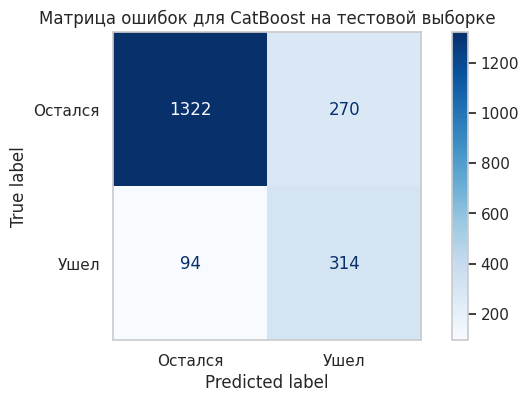

In [49]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Остался', 'Ушел'])

disp.plot(cmap='Blues', values_format='d')
plt.title('Матрица ошибок для CatBoost на тестовой выборке')
plt.grid(False)
plt.show()

Из 408 реально ушедших клиентов тестовой выборки модель успешно выявила 314 человек (метрика Recall — около 77%)

In [50]:
feature_importance = pd.DataFrame({
'Feature': X_train.columns,
'Importance': cb_grid_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
6,NumOfProducts,20.661004
3,Age,20.211664
5,Balance,12.126480
1,Geography,8.750334
9,EstimatedSalary,7.086768
12,Point Earned,6.786497
8,IsActiveMember,5.820145
0,CreditScore,5.278498
4,Tenure,4.787474
2,Gender,3.200874


In [51]:
explainer = shap.TreeExplainer(cb_grid_model)

In [52]:
shap_values = explainer(X_test)

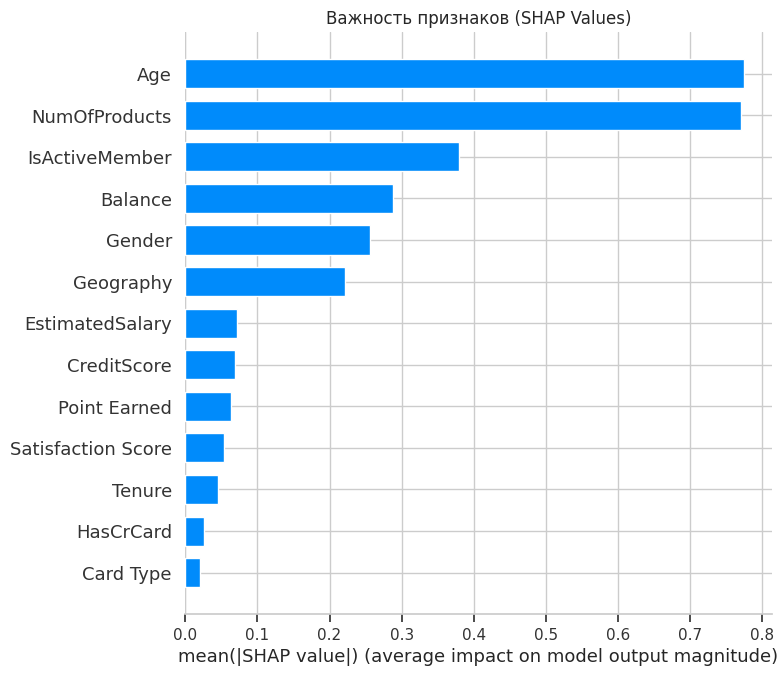

In [53]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Важность признаков (SHAP Values)")
plt.show()

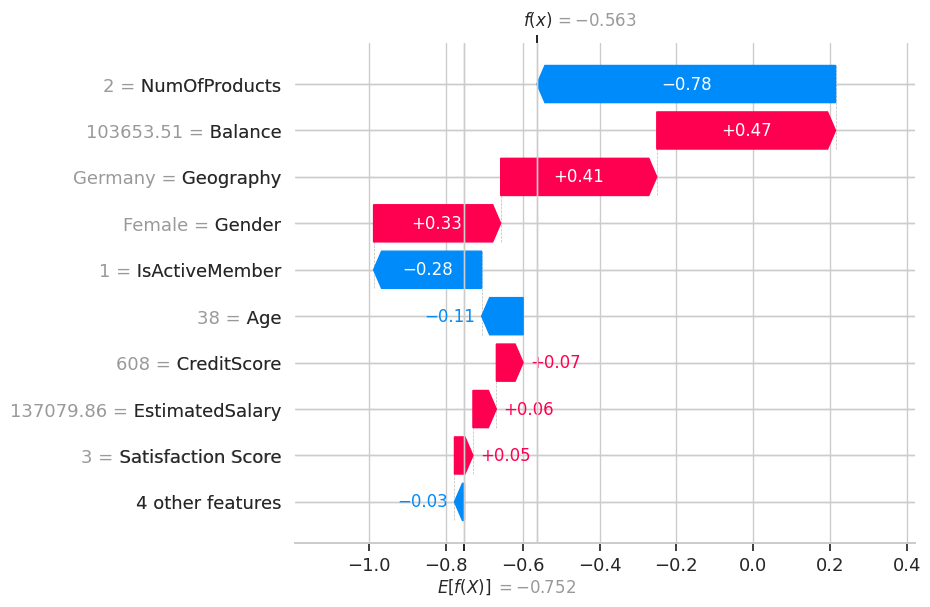

In [54]:
shap.plots.waterfall(shap_values[0])

график говорит почему конкретно этот клиент получил такой прогноз

In [55]:
X_test.iloc[100]

,4758
CreditScore,493
Geography,Spain
Gender,Female
Age,48
Tenure,7
Balance,0.0
NumOfProducts,2
HasCrCard,1
IsActiveMember,0
EstimatedSalary,48545.1


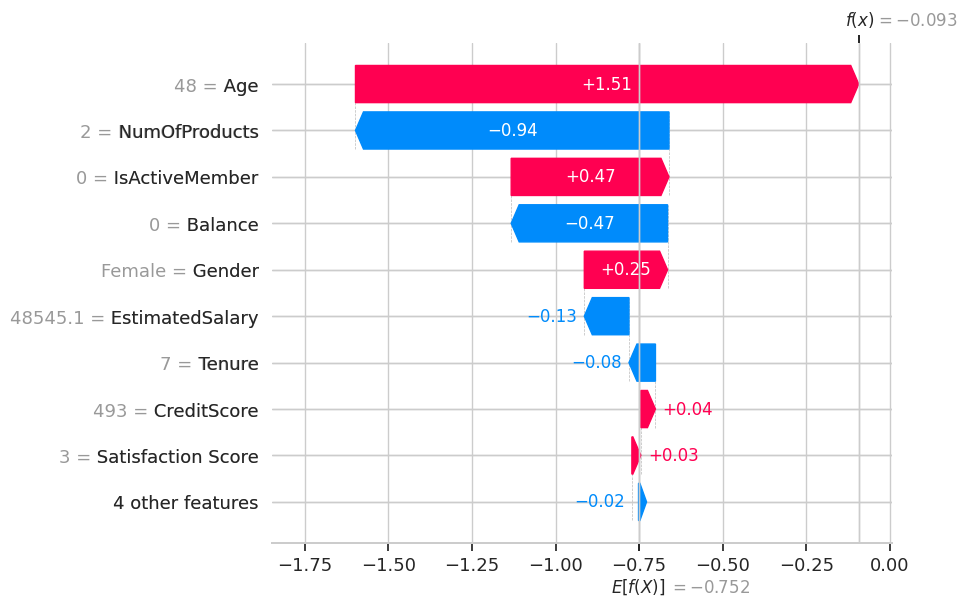

In [56]:
shap.plots.waterfall(shap_values[100])

In [57]:

models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "model.joblib"
joblib.dump(cb_grid_model, model_path)

print("Модель сохранена в:", model_path)

Модель сохранена в: models/model.joblib


In [ ]:
#files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
cb_grid_model.save_model("model.cbm")